# IPL Matches Analysis (2008 - 2019)

In [4]:
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df1=pd.read_csv('matches (1) (1).csv')
df2=pd.read_csv('deliveries (1) (1) (1).csv')

In [8]:
df1.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [7]:
df1.tail()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
751,11347,2019,Mumbai,05/05/19,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi
752,11412,2019,Chennai,07/05/19,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN
754,11414,2019,Visakhapatnam,10/05/19,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin
755,11415,2019,Hyderabad,12/05/19,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong


In [9]:
df2.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [11]:
df2.tail()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179077,11415,2,Chennai Super Kings,Mumbai Indians,20,6,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,0,0,0,SN Thakur,lbw,NaN


In [10]:
print(f"No. of rows and columns in matches data : {df1.shape}")
print(f"No. of rows and columns in deliveries data : {df2.shape}")

No. of rows and columns in matches data : (756, 18)
No. of rows and columns in deliveries data : (179078, 21)


In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [16]:
df1.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
751    False
752    False
753    False
754    False
755    False
Length: 756, dtype: bool

In [18]:
df2.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
179073    False
179074    False
179075    False
179076    False
179077    False
Length: 179078, dtype: bool

In [20]:
df1.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [22]:
df1.fillna({'city':'Unknown'}, inplace=True)

In [24]:
df1.loc[df1['result'] == 'no result', 'winner'] = df1['winner'].fillna('No winner')

In [26]:
df1.loc[df1['result'] == 'no result', 'player_of_match'] = df1['player_of_match'].fillna('Nobody due to no result')

In [28]:
df1.fillna({'umpire1':'Umpire unknown'}, inplace=True)

In [30]:
df1.fillna({'umpire2':'Umpire unknown'}, inplace=True)

In [32]:
df1.fillna({'umpire3':'Umpire unknown'}, inplace=True)

In [34]:
df1['team1'] = df1['team1'].replace('Rising Pune Supergiants', 'Rising Pune Supergiant')

In [36]:
df1['team2'] = df1['team2'].replace('Rising Pune Supergiants', 'Rising Pune Supergiant')

In [38]:
df1['winner'] = df1['winner'].replace('Rising Pune Supergiants', 'Rising Pune Supergiant')

In [40]:
df1.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
umpire3            0
dtype: int64

In [42]:
df2.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

In [44]:
df2.fillna({'player_dismissed':'No wicket'}, inplace=True)
df2.fillna({'dismissal_kind':'No wicket'}, inplace=True)
df2.fillna({'fielder':'No wicket'}, inplace=True)

In [229]:
df2['batting_team'] = df2['batting_team'].replace('Rising Pune Supergiants', 'Rising Pune Supergiant')
df2['bowling_team'] = df2['bowling_team'].replace('Rising Pune Supergiants', 'Rising Pune Supergiant')

In [231]:
df2.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
non_striker         0
bowler              0
is_super_over       0
wide_runs           0
bye_runs            0
legbye_runs         0
noball_runs         0
penalty_runs        0
batsman_runs        0
extra_runs          0
total_runs          0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [233]:
df1.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [235]:
df2.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000
mean,1802.252957,1.482952,10.162488,3.615587,0.000452,0.036721,0.004936,0.021136,0.004183,0.000056,1.246864,0.067032,1.313897
std,3472.322805,0.502074,5.677684,1.806966,0.021263,0.251161,0.116480,0.194908,0.070492,0.016709,1.608270,0.342553,1.605422
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,379.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,567.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,11415.000000,5.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,7.000000,7.000000,10.000000


### Total number of innings of the matches played

In [237]:
total_innings = df2.groupby(['match_id', 'inning'])
print(f"Total innings played: {total_innings.ngroups}")

Total innings played: 1528


### How many IPL seasons are we using to analyse ?

In [239]:
seasons = df1['season'].nunique()
print(f"Total no. of seasons used for analysing : {seasons}")

Total no. of seasons used for analysing : 12


### Total number of matches played according to the dataset

In [56]:
Total_matches_played=df1[df1['result'] != 'no result']['id'].nunique()
print(f"Total matches played (excluding no results): {Total_matches_played}")

Total matches played (excluding no results): 752


### Which IPL team won by maximum runs?

In [58]:
won_by_max_runs = df1.loc[df1['win_by_runs'].idxmax()]['winner']
print(f"Team won by maximum runs : {won_by_max_runs}")

Team won by maximum runs : Mumbai Indians


### Which IPL team won by minimum runs?

In [60]:
won_by_min_runs = df1.loc[df1[df1['win_by_runs'] > 0]['win_by_runs'].idxmin()]['winner']
print(f"Team won by minimum runs : {won_by_min_runs}")

Team won by minimum runs : Mumbai Indians


### Which IPL team won by consuming maximum wickets?

In [62]:
max_wicket_value = df1['win_by_wickets'].max()
won_by_max_wickets = df1[df1['win_by_wickets'] == max_wicket_value]['winner'].unique()
print(f"Teams won by maximum wickets : {',\n'.join(won_by_max_wickets)}")

Teams won by maximum wickets : Kolkata Knight Riders,
Kings XI Punjab,
Deccan Chargers,
Delhi Daredevils,
Royal Challengers Bangalore,
Rajasthan Royals,
Mumbai Indians,
Chennai Super Kings,
Sunrisers Hyderabad


### Which IPL team won by consuming minimum wickets?

In [64]:
min_wicket_value = df1[df1['win_by_wickets'] > 0]['win_by_wickets'].min()
won_by_min_wickets = df1[df1['win_by_wickets'] == min_wicket_value]['winner'].unique()
print(f"Teams won by minimum wickets : {",\n".join(won_by_min_wickets)}")

Teams won by minimum wickets : Kolkata Knight Riders,
Chennai Super Kings,
Sunrisers Hyderabad


### Which season consisted of the highest number of matches ever played?

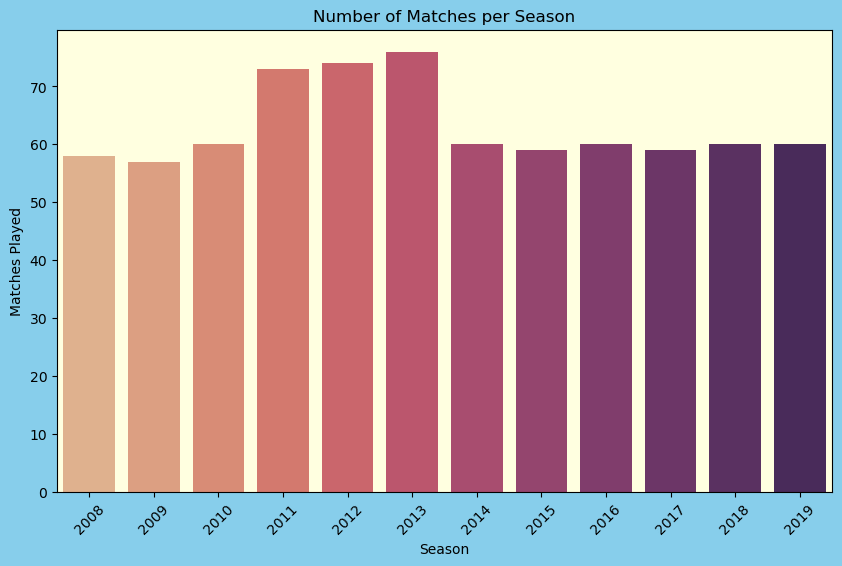

In [430]:
plt.figure(figsize=(10,6),facecolor='skyblue')
ax=sns.countplot(data=df1, x='season', hue='season', palette='flare', legend=False)
ax.set_facecolor('lightyellow')
plt.title('Number of Matches per Season')
plt.xlabel('Season')
plt.ylabel('Matches Played')
plt.xticks(rotation=45)
plt.show()

### Which is the most successful IPL team with all the data at hand?

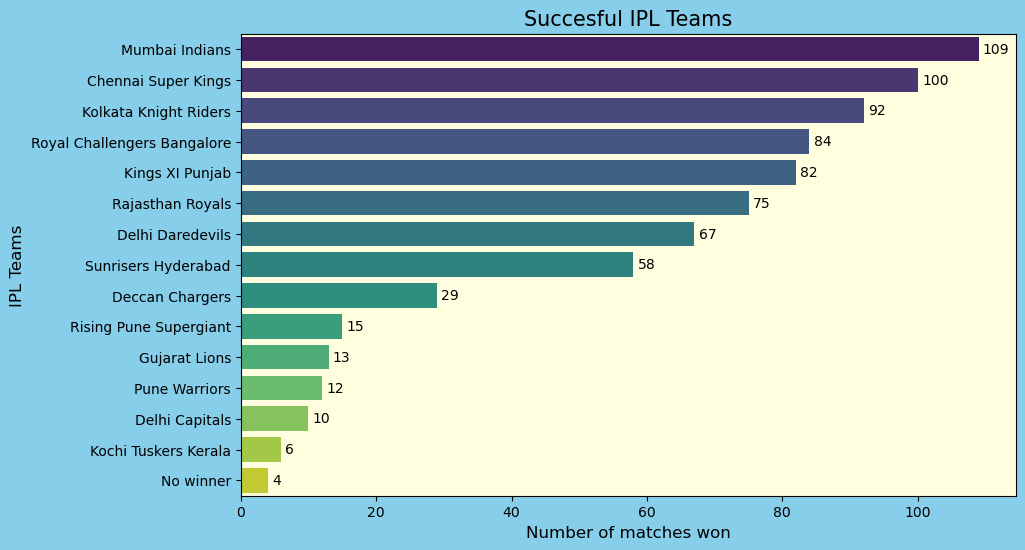

In [74]:
plt.figure(figsize=(10,6), facecolor='skyblue')
ax=sns.barplot(x=df1['winner'].value_counts().values, y=df1['winner'].value_counts().index, hue=df1['winner'].value_counts().index,
            palette='viridis', legend=False)
ax.set_facecolor('lightyellow')
for i in range(0,15):
    ax.bar_label(ax.containers[i], padding=3)

plt.title('Succesful IPL Teams', fontsize=15)
plt.xlabel('Number of matches won', fontsize=12)
plt.ylabel('IPL Teams', fontsize=12)
plt.show()

### Top players of winning matches

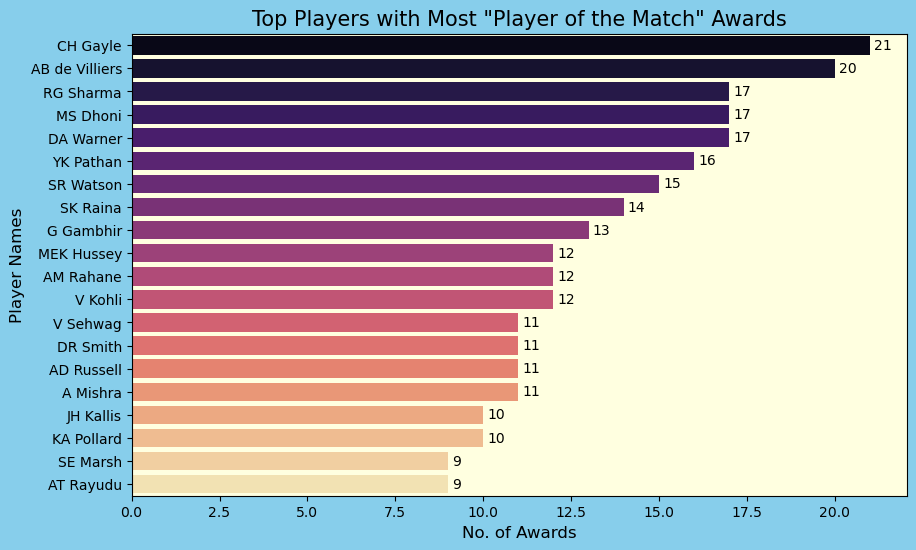

In [428]:
winning_match_players = df1['player_of_match'].value_counts().head(20)
plt.figure(figsize=(10,6),facecolor='skyblue')
ax=sns.barplot(x=winning_match_players.values, y=winning_match_players.index, hue=winning_match_players.index, palette='magma', legend=False)
ax.set_facecolor('lightyellow')
for i in range(0,20):
    ax.bar_label(ax.containers[i], padding=3)

plt.title('Top Players with Most "Player of the Match" Awards', fontsize=15)
plt.xlabel('No. of Awards',fontsize=12)
plt.ylabel('Player Names',fontsize=12)
plt.show()

### Matches according to venue

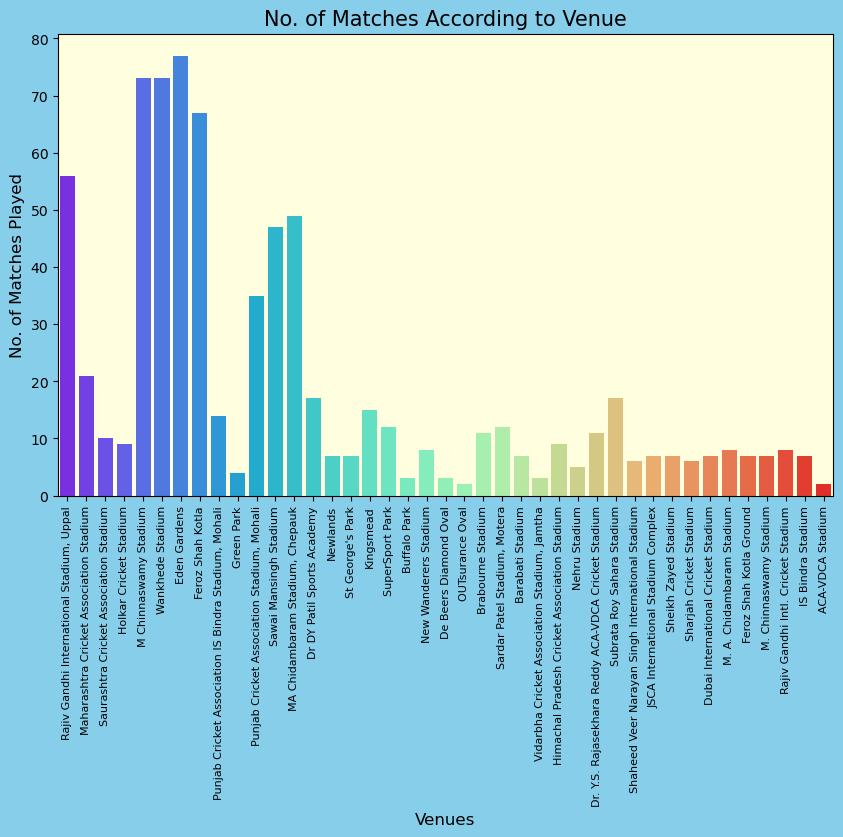

In [426]:
plt.figure(figsize=(10,6),facecolor='skyblue')
ax=sns.countplot(data=df1, x='venue', hue='venue', palette='rainbow', legend=False)
ax.set_facecolor('lightyellow')
plt.title('No. of Matches According to Venue', fontsize=15)
plt.xlabel('Venues', fontsize=12)
plt.ylabel('No. of Matches Played', fontsize=12)
plt.xticks(fontsize=8, rotation=90)
plt.show()

### The number of matches played by each team

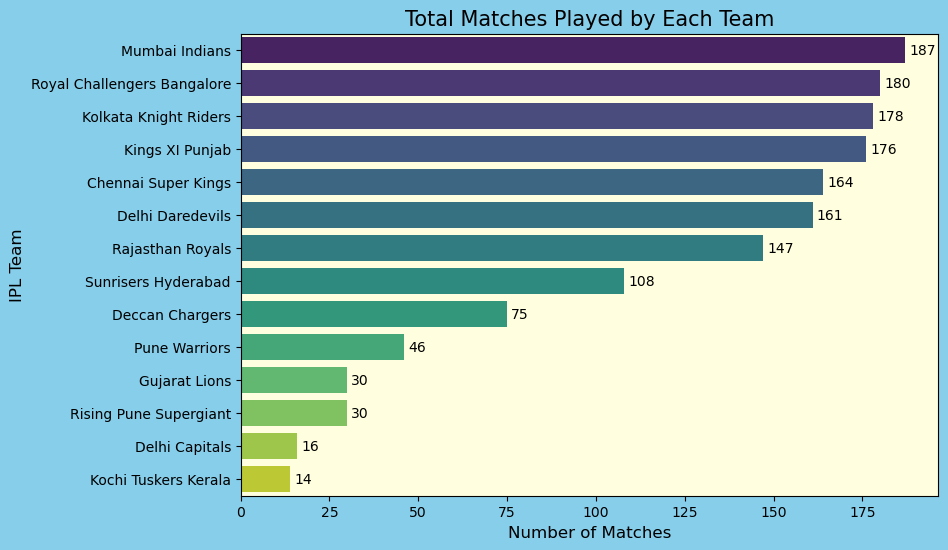

In [98]:
all_matches=df1['team1'].value_counts() + df1['team2'].value_counts()
all_matches=all_matches.sort_values(ascending=False)

plt.figure(figsize=(9,6), facecolor='skyblue')

ax = sns.barplot(x=all_matches.values, y=all_matches.index, hue=all_matches.index, palette='viridis')
ax.set_facecolor('lightyellow')

n=all_matches.count()
for i in range(0,n):
    ax.bar_label(ax.containers[i], padding=3)

plt.title('Total Matches Played by Each Team', fontsize=15)
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('IPL Team', fontsize=12)
plt.show()

### The winners in each Season

IPL Champions by Season:
    season                 winner
0     2008       Rajasthan Royals
1     2009        Deccan Chargers
2     2010    Chennai Super Kings
3     2011    Chennai Super Kings
4     2012  Kolkata Knight Riders
5     2013         Mumbai Indians
6     2014  Kolkata Knight Riders
7     2015         Mumbai Indians
8     2016    Sunrisers Hyderabad
9     2017         Mumbai Indians
10    2018    Chennai Super Kings
11    2019         Mumbai Indians


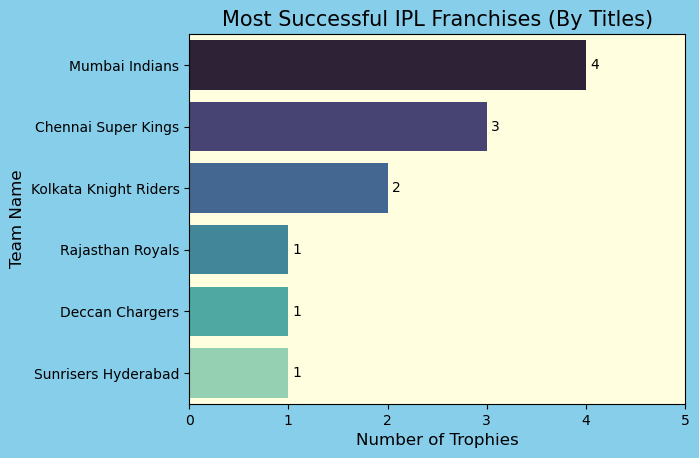

In [412]:
season_winners=df1.drop_duplicates(subset=['season'], keep='last')[['season', 'winner']]
season_winners=season_winners.sort_values('season').reset_index(drop=True)

print("IPL Champions by Season:")
print(season_winners)
title_counts=season_winners['winner'].value_counts()

plt.figure(facecolor='skyblue')

ax=sns.barplot(x=title_counts.values, y=title_counts.index, hue=title_counts.index, palette='mako')
ax.set_facecolor('lightyellow')

n=title_counts.count()
for i in range(0,n):
    ax.bar_label(ax.containers[i], padding=3)

plt.title('Most Successful IPL Franchises (By Titles)', fontsize=15)
plt.xlabel('Number of Trophies', fontsize=12)
plt.ylabel('Team Name',fontsize=12)
plt.xticks(np.arange(0,6,step=1))
plt.show()

### IPL Finals venues and winners along with the number of wins.

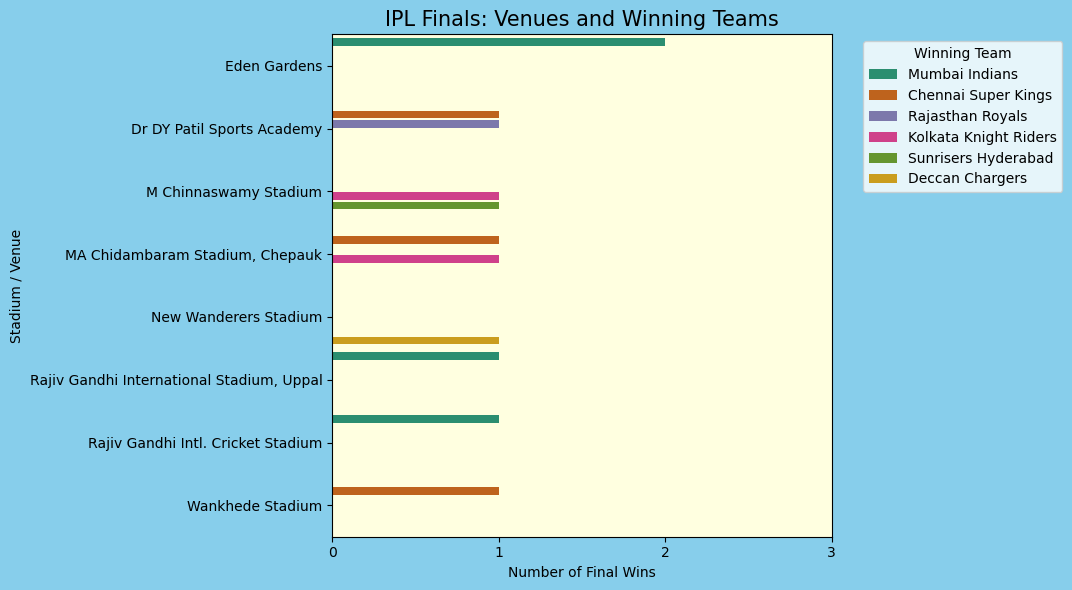

In [424]:
finals = df1.drop_duplicates(subset=['season'], keep='last')

venue_winners = finals.groupby(['venue', 'winner']).size().reset_index(name='wins')
venue_winners = venue_winners.sort_values(by='wins', ascending=False)

plt.figure(figsize=(11, 6), facecolor='skyblue')
ax = sns.barplot(data=venue_winners, x='wins', y='venue', hue='winner', palette='Dark2', width=0.9, gap=0.2)
ax.set_facecolor('lightyellow')

plt.title('IPL Finals: Venues and Winning Teams', fontsize=15)
plt.xlabel('Number of Final Wins')
plt.ylabel('Stadium / Venue')
plt.xticks(np.arange(0,4,1))

plt.legend(title='Winning Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### The number of seasons won by each team

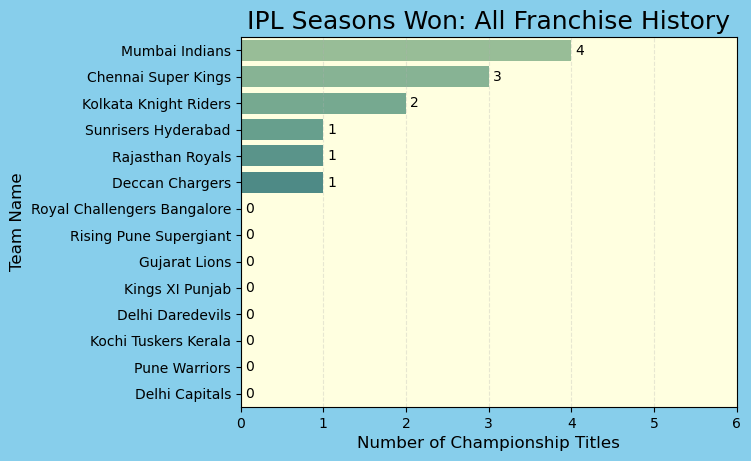

In [200]:
teams=pd.unique(df1[['team1','team2']].values.ravel())
season_winners=df1.drop_duplicates('season', keep='last')
winners_counts=season_winners['winner'].value_counts()

final_data = []
for team in teams:
    wins = winners_counts.get(team, 0)
    final_data.append({'Team': team, 'Seasons Won': wins})

df3=pd.DataFrame(final_data).sort_values(by='Seasons Won', ascending=False)

plt.figure(facecolor='skyblue')
ax=sns.barplot(x='Seasons Won', y='Team', hue='Team', data=df3, palette='crest', legend=False)
ax.set_facecolor('lightyellow')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('IPL Seasons Won: All Franchise History', fontsize=18)
plt.xlabel('Number of Championship Titles', fontsize=12)
plt.ylabel('Team Name', fontsize=12)
plt.xticks(range(0, 7))
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

### Decision in every toss either fielding or batting

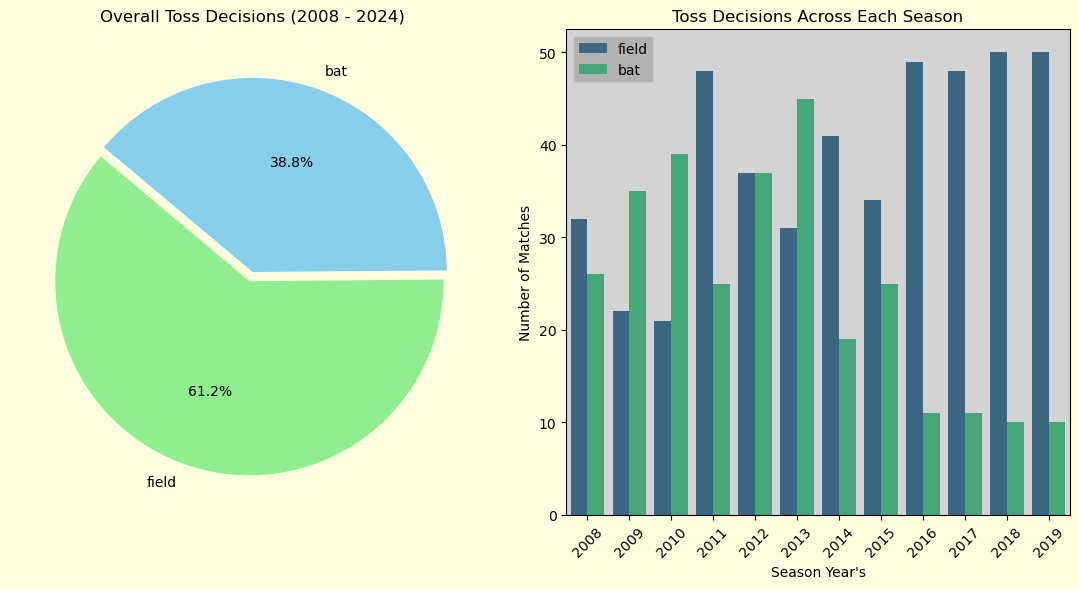

In [188]:
toss_counts = df1['toss_decision'].value_counts()

plt.figure(figsize=(11, 6), facecolor='lightyellow')

plt.subplot(1, 2, 1)
plt.pie(toss_counts, labels=toss_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'skyblue'], explode=(0.05, 0))
plt.title('Overall Toss Decisions (2008 - 2024)')

plt.subplot(1, 2, 2)
ax=sns.countplot(x='season', hue='toss_decision', data=df1, palette='viridis')
ax.set_facecolor('lightgray')
plt.legend(facecolor='darkgray')
plt.title('Toss Decisions Across Each Season')
plt.xticks(rotation=45)
plt.xlabel('''Season Year's''')
plt.ylabel('Number of Matches')

plt.tight_layout()
plt.show()

### What is the probability of winning a match if the toss was won?

In [224]:
df1 = df1.dropna(subset=["toss_winner", "winner"])
df1["toss_win_match_win"]=df1["toss_winner"] == df1["winner"]
total_toss_wins=len(df1)
toss_and_match_wins=df1["toss_win_match_win"].sum()

probability=toss_and_match_wins / total_toss_wins

print(f"Probability of winning match given toss was won: {probability*100 :.2f}%")

Probability of winning match given toss was won: 51.59%


### The total runs by fours hit and the total number of fours hit by each team

                   batting_team  total_no_of_fours  total_runs_by_fours
8                Mumbai Indians               2588                10352
5               Kings XI Punjab               2458                 9832
7         Kolkata Knight Riders               2434                 9736
12  Royal Challengers Bangalore               2360                 9440
0           Chennai Super Kings               2193                 8772
3              Delhi Daredevils               2158                 8632
10             Rajasthan Royals               2035                 8140
13          Sunrisers Hyderabad               1444                 5776
1               Deccan Chargers                957                 3828
9                 Pune Warriors                525                 2100
4                 Gujarat Lions                460                 1840
11       Rising Pune Supergiant                368                 1472
2                Delhi Capitals                242              

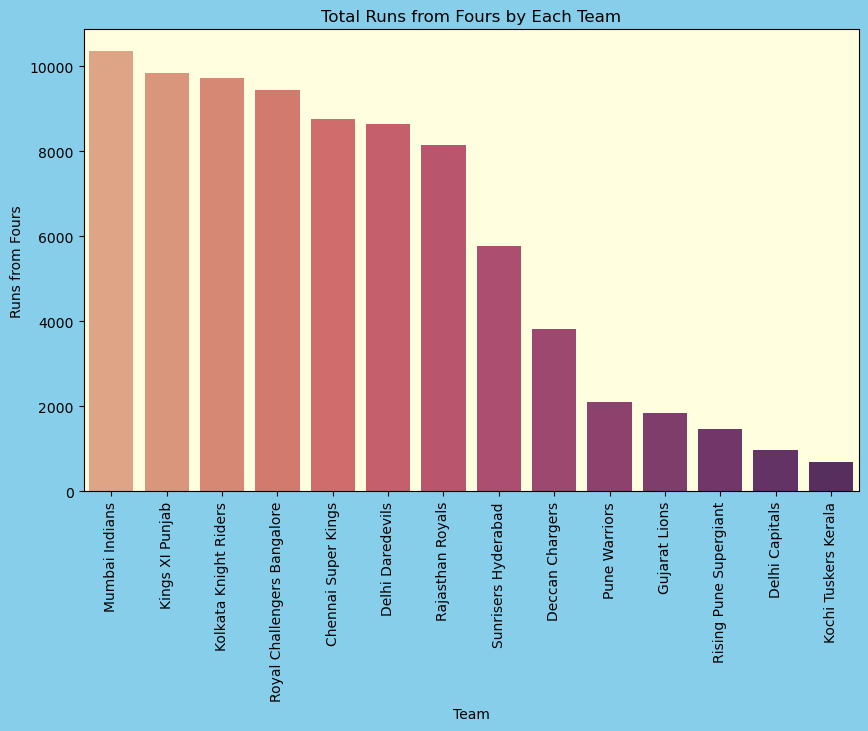

In [408]:
fours_df=df2[df2["batsman_runs"] == 4]

result=fours_df.groupby("batting_team").agg(
    total_no_of_fours=("batsman_runs", "count"),
    total_runs_by_fours=("batsman_runs", "sum")
).reset_index()

result=result.sort_values(by='total_no_of_fours', ascending=False)
print(result)

plt.figure(figsize=(10,6), facecolor='skyblue')

ax=sns.barplot(x=result["batting_team"], y=result["total_runs_by_fours"], hue=result["batting_team"], palette='flare', legend=False)
ax.set_facecolor('lightyellow')

plt.xticks(rotation=90)
plt.title("Total Runs from Fours by Each Team")
plt.xlabel("Team")
plt.ylabel("Runs from Fours")
plt.show()

### The fours hit by players

         Player  Total_Fours
317    S Dhawan          526
343    SK Raina          495
120   G Gambhir          492
387     V Kohli          482
89    DA Warner          459
310  RV Uthappa          436
295   RG Sharma          431
36    AM Rahane          405
77     CH Gayle          376
265    PA Patel          366


Total no. of fours hit by players : 20392




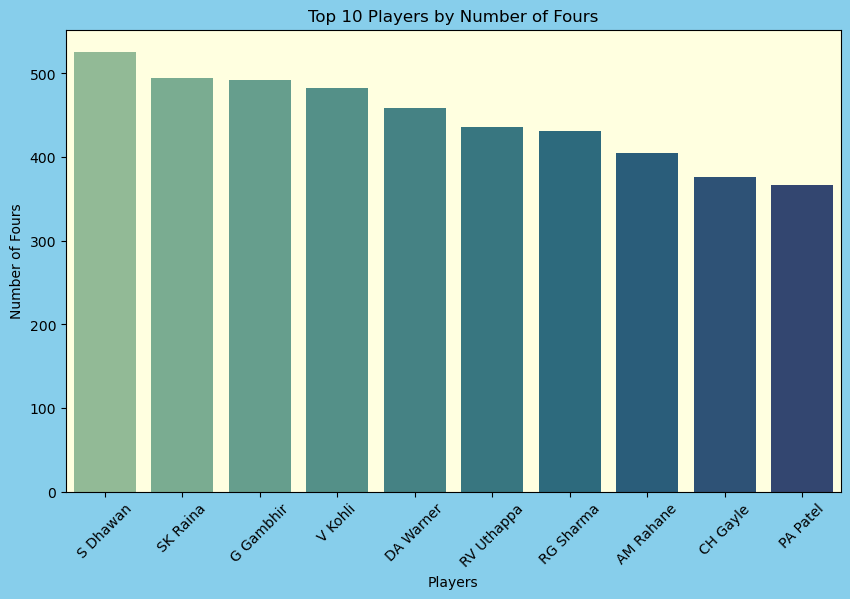

In [322]:
fours_df = df2[df2["batsman_runs"] == 4]
no_of_fours_by_players = fours_df.groupby('batsman')['batsman_runs'].count().reset_index()

no_of_fours_by_players.columns = ["Player", "Total_Fours"]
no_of_fours_by_players = no_of_fours_by_players.sort_values(by='Total_Fours', ascending=False)
print(no_of_fours_by_players.head(10))
print('\n')
print(f"Total no. of fours hit by players : {no_of_fours_by_players['Total_Fours'].sum()}")
print('\n')

plt.figure(figsize=(10,6), facecolor='skyblue')
ax=sns.barplot(x=no_of_fours_by_players["Player"].head(10), y=no_of_fours_by_players["Total_Fours"].head(10), 
               hue=no_of_fours_by_players["Player"].head(10), palette='crest', legend=False)
ax.set_facecolor('lightyellow')

plt.xticks(rotation=45)
plt.title("Top 10 Players by Number of Fours")
plt.xlabel("Players")
plt.ylabel("Number of Fours")
plt.show()

### The number of fours hit in each season

    Season  Total_Fours
0     2008         1703
1     2009         1321
2     2010         1709
3     2011         1916
4     2012         1911
5     2013         2054
6     2014         1563
7     2015         1611
8     2016         1633
9     2017         1612
10    2018         1674
11    2019         1685


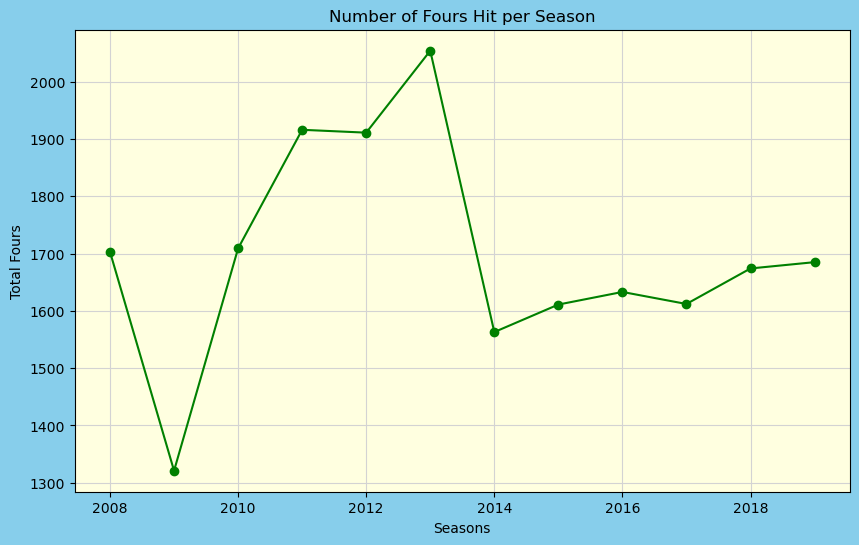

In [355]:
fdf = df2.merge(df1, left_on="match_id", right_on="id")
fours_df = fdf[fdf["batsman_runs"] == 4]
fours_per_season = fours_df.groupby("season")["batsman_runs"].count().reset_index()
fours_per_season.columns = ["Season", "Total_Fours"]

print(fours_per_season)

plt.figure(figsize=(10,6), facecolor='skyblue')
plt.plot(fours_per_season["Season"], fours_per_season["Total_Fours"], marker='o', color='green')
plt.gca().set_facecolor('lightyellow')
plt.title("Number of Fours Hit per Season")
plt.xlabel("Seasons")
plt.ylabel("Total Fours")
plt.grid(True, color='lightgray')
plt.show()

### The total runs by the sixes hit and the number of sixes hit by each team

                   batting_team  total_no_of_sixes  total_runs_by_sixes
12  Royal Challengers Bangalore               1134                 6806
8                Mumbai Indians               1099                 6597
0           Chennai Super Kings                976                 5859
5               Kings XI Punjab                976                 5856
7         Kolkata Knight Riders                932                 5594
3              Delhi Daredevils                801                 4806
10             Rajasthan Royals                681                 4086
13          Sunrisers Hyderabad                534                 3205
1               Deccan Chargers                400                 2400
9                 Pune Warriors                196                 1176
11       Rising Pune Supergiant                157                  942
4                 Gujarat Lions                155                  930
2                Delhi Capitals                 87              

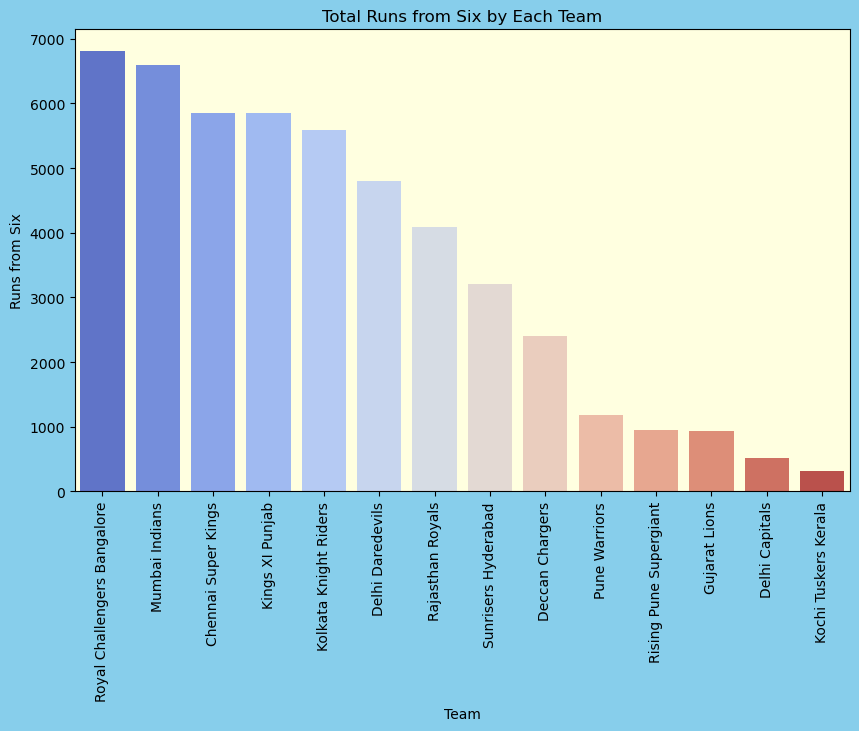

In [368]:
sixes_df=df2[df2["batsman_runs"] >= 6]

result=sixes_df.groupby("batting_team").agg(
    total_no_of_sixes=("batsman_runs", "count"),
    total_runs_by_sixes=("batsman_runs", "sum")
).reset_index()

result=result.sort_values(by='total_no_of_sixes', ascending=False)
print(result)

plt.figure(figsize=(10,6), facecolor='skyblue')

ax=sns.barplot(x=result["batting_team"], y=result["total_runs_by_sixes"], hue=result["batting_team"], palette='coolwarm', legend=False)
ax.set_facecolor('lightyellow')

plt.xticks(rotation=90)
plt.title("Total Runs from Six by Each Team")
plt.xlabel("Team")
plt.ylabel("Runs from Six")
plt.show()

### The number of sixes hit in each season

    Season  Total_Six
0     2008        623
1     2009        508
2     2010        587
3     2011        639
4     2012        733
5     2013        681
6     2014        715
7     2015        692
8     2016        639
9     2017        706
10    2018        872
11    2019        786


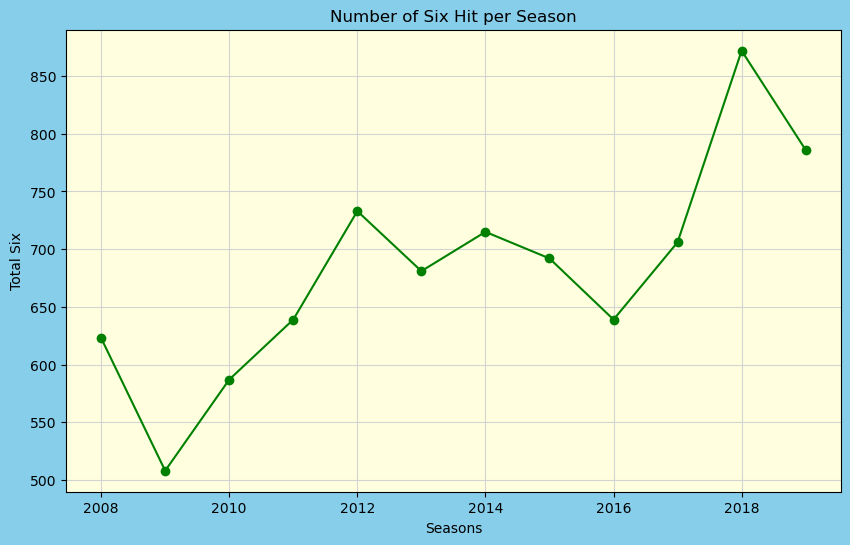

In [377]:
sdf = df2.merge(df1, left_on="match_id", right_on="id")
six_df = sdf[sdf["batsman_runs"] >= 6]
six_per_season = six_df.groupby("season")["batsman_runs"].count().reset_index()
six_per_season.columns = ["Season", "Total_Six"]

print(six_per_season)

plt.figure(figsize=(10,6), facecolor='skyblue')
plt.plot(six_per_season["Season"], six_per_season["Total_Six"], marker='o', color='green')
plt.gca().set_facecolor('lightyellow')
plt.title("Number of Six Hit per Season")
plt.xlabel("Seasons")
plt.ylabel("Total Six")
plt.grid(True, color='lightgray')
plt.show()

### The top 10 leading run scorers in IPL

             Player  Total_Runs
486         V Kohli        5434
428        SK Raina        5415
367       RG Sharma        4914
112       DA Warner        4741
392        S Dhawan        4632
92         CH Gayle        4560
290        MS Dhoni        4477
384      RV Uthappa        4446
26   AB de Villiers        4428
147       G Gambhir        4223


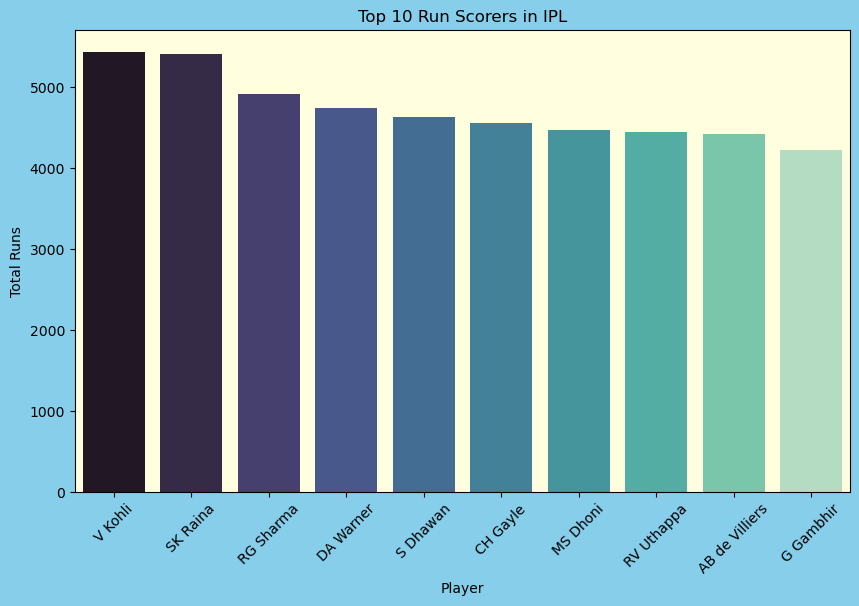

In [406]:
top_scorers = df2.groupby("batsman")["batsman_runs"].sum().reset_index()
top_scorers.columns = ["Player", "Total_Runs"]
top10 = top_scorers.sort_values(by="Total_Runs", ascending=False).head(10)
print(top10)

plt.figure(figsize=(10,6), facecolor='skyblue')
sns.barplot(x=top10["Player"], y=top10["Total_Runs"], hue=top10["Player"], palette='mako', legend=False)
plt.gca().set_facecolor('lightyellow')
plt.xticks(rotation=45)
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.show()

# Conclusion